In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from scipy.io.wavfile import write
import subprocess
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import pickle as pkl
from geolib import geohash as geolib
import warnings
#warnings.filterwarnings("ignore", message="urllib3 v2.0")

In [67]:
# Geohashes in switzerland
#swiss_geohashes = [f"u0{c}" for c in "kmqrhjnp"]
# Keep only bern
#swiss_geohashes = ["u0m7"]
# Keep all world
swiss_geohashes = [f"{a}" for a in "0123456789bcdefghjkmnpqrstuvwxyz"]

# Translate selected modes of transport to corresponding actual transport modes
def translate_mot(mot):
    if mot == "CAR" or mot == "ELECTRIC_CAR" or mot == "HYBRID_CAR":
        return "Car"
    elif mot == "TRAIN":
        return "Train"
    elif mot == "WALKING":
        return "Walking"
    elif mot == "ON_BICYCLE" or mot == "ELECTRIC_BIKE" or mot == "SCOOTER" or mot == "ELECTRIC_SCOOTER":
        return "Bicycle"
    elif mot == "BUS" or mot == "ELECTRIC_BUS" or mot == "COACH":
        return "Bus"
    elif mot == "TRAM":
        return "Tram"
    elif mot == "PLANE":
        return "Plane"
    elif mot == "BOAT" or mot == "BOAT_NO_ENGINE":
        return "Boat"
    else:
        return mot
    
# Read geohashes to coordinates mapping (dataframe with columns: geohash, latitude, longitude)
geo_to_coords = pd.read_pickle('geohashes_to_coords.pkl')

# Function to complete geo_to_coords with missing geohashes
def complete_geo_to_coords(geo_to_coords, geohashes):
    missing_geohashes = set(geohashes) - set(geo_to_coords['geohash'])
    new_rows = []
    for gh in missing_geohashes:
        lat, lon = geolib.decode(gh)
        new_rows.append({'geohash': gh, 'latitude': lat, 'longitude': lon})
    if new_rows:
        geo_to_coords = pd.concat([geo_to_coords, pd.DataFrame(new_rows)], ignore_index=True)
        geo_to_coords.to_pickle('geohashes_to_coords.pkl') # Save to file
    return geo_to_coords

In [68]:
# Read data
df = pd.read_csv('data/all_movements_112.csv', sep=";")

In [69]:
# Keep only moveents longer than 5 km
df = df[df['distance(m)'] >= 5000]

In [70]:
# Keep only data in switzerland
df = df[(df['start_geohash'].str.startswith(tuple(swiss_geohashes))) & (df['end_geohash'].str.startswith(tuple(swiss_geohashes)))]

# Translate mean of transport by simplifying (e.g., CAR, ELECTRIC_CAR, HYBRID_CAR -> CAR)
df['mean_of_transport'] = df['mean_of_transport'].apply(translate_mot)

In [71]:
all_geohashes = set(df['start_geohash']).union(set(df['end_geohash']))
geo_to_coords = complete_geo_to_coords(geo_to_coords, all_geohashes)

In [72]:
# Translate all start and end geohashes to coordinates
start_coords = df['start_geohash'].map(geo_to_coords.set_index('geohash')[['latitude', 'longitude']].to_dict(orient='index'))
end_coords = df['end_geohash'].map(geo_to_coords.set_index('geohash')[['latitude', 'longitude']].to_dict(orient='index'))

df['start_lat'] = start_coords.apply(lambda x: float(x['latitude']))
df['start_lon'] = start_coords.apply(lambda x: float(x['longitude']))
df['end_lat'] = end_coords.apply(lambda x: float(x['latitude']))
df['end_lon'] = end_coords.apply(lambda x: float(x['longitude']))

In [73]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [74]:
# Times are saved as UTC, convert to local time (CET/CEST)
df['start_time'] = df['start_time'].dt.tz_convert('Europe/Zurich')
df['end_time'] = df['end_time'].dt.tz_convert('Europe/Zurich')

In [75]:
df["start_hour"] = df["start_time"].dt.hour + df["start_time"].dt.minute/60
df["end_hour"]   = df["end_time"].dt.hour + df["end_time"].dt.minute/60

In [76]:
df['duration'] = abs(df['end_hour'] - df['start_hour'])

In [77]:
df

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,start_lat,start_lon,end_lat,end_lon,start_hour,end_hour,duration
10,219935XE1,2024-08-28 09:06:08+02:00,2024-08-28 09:24:07+02:00,u0m714,u0m468,30622,Train,TRAIN,214,False,46.947327,7.432251,46.804504,7.146606,9.100000,9.400000,0.300000
16,219935XE1,2024-08-28 09:06:16+02:00,2024-08-28 09:24:31+02:00,u0m714,u0m468,37343,Train,TRAIN,261,False,46.947327,7.432251,46.804504,7.146606,9.100000,9.400000,0.300000
21,219935XE1,2024-08-28 18:12:44+02:00,2024-08-28 18:26:01+02:00,u0m468,u0m4tv,14580,Train,TRAIN,102,False,46.804504,7.146606,46.875916,7.289429,18.200000,18.433333,0.233333
26,219935XE1,2024-08-28 18:12:53+02:00,2024-08-28 18:39:50+02:00,u0m468,u0m709,26135,Train,TRAIN,182,False,46.804504,7.146606,46.941833,7.410278,18.200000,18.650000,0.450000
29,219935XE1,2024-08-29 09:21:50+02:00,2024-08-29 09:58:28+02:00,u0m709,u0m468,30717,Train,TRAIN,215,False,46.941833,7.410278,46.804504,7.146606,9.350000,9.966667,0.616667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33953,5S4G1W,2025-10-14 04:27:16+02:00,2025-10-14 04:56:08+02:00,u0qnnq,u0qjt3,13716,Car,CAR,2551,True,47.496643,8.717651,47.381287,8.673706,4.450000,4.933333,0.483333
33957,7J7DXM,2025-10-11 23:04:40+02:00,2025-10-11 23:11:15+02:00,u0qjfy,u0qj9f,8879,Train,TRAIN,62,False,47.452698,8.563843,47.386780,8.519897,23.066667,23.183333,0.116667
33963,7J7DXM,2025-10-13 08:13:33+02:00,2025-10-13 08:40:25+02:00,u0qj9f,u0qnnr,24528,Train,TRAIN,171,False,47.386780,8.519897,47.502136,8.717651,8.216667,8.666667,0.450000
33966,7J7DXM,2025-10-13 17:38:15+02:00,2025-10-13 18:07:07+02:00,u0qnnx,u0qj9c,24887,Train,TRAIN,174,False,47.502136,8.728638,47.381287,8.519897,17.633333,18.116667,0.483333


In [78]:
from shapely.geometry import box

# ---------- Color palette ----------
color_map = {
    'Train': 'deepskyblue',
    'Tram': 'orchid',
    'Bus': 'gold',
    'Walking': 'lime',
    'Bicycle': 'tomato',
    'Car': 'orange'
}

# ---------- Create projected GeoDataFrame ----------
start_points = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df.start_lon, df.start_lat)],
    crs="EPSG:4326"
)
start_points = start_points.to_crs(epsg=3857)

# Define Swiss map bounds - CORRECTED
xmin, ymin, xmax, ymax = 5.71, 45.2, 10.8, 47.95
bbox_polygon = box(xmin, ymin, xmax, ymax)
bbox = gpd.GeoSeries([bbox_polygon], crs="EPSG:4326").to_crs(epsg=3857).total_bounds

# ---------- Figure setup ----------
fig, ax = plt.subplots(figsize=(12, 10), facecolor='black')  # Larger figure, black background
ax.set_axis_off()
ax.set_title("Commuter Symphony", color="white", fontsize=16, pad=20)
ax.set_facecolor('black')

# Set bounds BEFORE adding basemap
ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])

# Try different basemap providers (uncomment one):
try:
    # Option 1: CartoDB DarkMatter (your current choice)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter, zoom='auto', crs="EPSG:3857")
    
    # Option 2: Stamen TonerLite (good alternative)
    # ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite, zoom='auto', crs="EPSG:3857")
    
    # Option 3: OpenStreetMap (fallback)
    # ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom='auto', crs="EPSG:3857")
    
    # Option 4: CartoDB Positron (light background)
    # ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto', crs="EPSG:3857")
    
except Exception as e:
    print(f"⚠️ Basemap failed to load: {e}")
    print("Continuing without basemap...")

# Prepare scatter plot
scat = ax.scatter([], [], s=10, alpha=0.8, edgecolors='white', linewidths=0.3)

# ---------- Animation update ----------
def update(t):
    active = df[(df.start_hour <= t) & (df.end_hour >= t)]
    if active.empty:
        scat.set_offsets(np.empty((0, 2)))
        return scat,
    
    frac = (t - active.start_hour) / active.duration
    lats = active.start_lat + frac * (active.end_lat - active.start_lat)
    lons = active.start_lon + frac * (active.end_lon - active.start_lon)
    
    temp_gdf = gpd.GeoDataFrame(
        geometry=[Point(xy) for xy in zip(lons, lats)],
        crs="EPSG:4326"
    ).to_crs(epsg=3857)
    
    scat.set_offsets(np.column_stack([temp_gdf.geometry.x, temp_gdf.geometry.y]))
    scat.set_color([color_map.get(m, "white") for m in active["mean_of_transport"]])
    
    return scat,

# Rest of your code remains the same...
ani = FuncAnimation(fig, update, frames=np.linspace(0, 24, 720), interval=1000/30, blit=True)

# ... (sound generation code stays the same)

# ---------- Sound generation ----------
sample_rate = 44100
total_duration = 24  # hours → seconds
samples = np.zeros(int(sample_rate * total_duration))

freq_map = {
    'Train': 440,      # A4
    'Tram': 554,       # C#5
    'Bus': 659,        # E5
    'Walking': 880,    # A5
    'Bicycle': 988,    # B5
    'Car': 1318        # E6
}

tone_duration = 0.1  # seconds per note

for _, row in df.iterrows():
    start_sec = (row["start_hour"] / 24) * total_duration
    start_idx = int(start_sec * sample_rate)
    freq = freq_map.get(row["mean_of_transport"], 440)
    t = np.linspace(0, tone_duration, int(sample_rate * tone_duration), endpoint=False)
    amp = np.clip(row["duration"] / 4, 0.3, 1.0)
    tone = 0.5 * amp * np.sin(2 * np.pi * freq * t)
    end_idx = min(start_idx + len(tone), len(samples))
    samples[start_idx:end_idx] += tone[:end_idx - start_idx]

samples = samples / np.max(np.abs(samples))
write("commuter_symphony.wav", sample_rate, (samples * 32767).astype(np.int16))
# ---------- Save animation using FFmpeg writer ----------
writer = FFMpegWriter(fps=30, bitrate=1800, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
ani.save("commuter_symphony_noaudio.mp4", writer=writer, dpi=100)

plt.close(fig)

# ---------- Merge video + audio ----------
cmd = [
    "ffmpeg", "-y",
    "-i", "commuter_symphony_noaudio.mp4",
    "-i", "commuter_symphony.wav",
    "-map", "0:v:0", "-map", "1:a:0",
    "-c:v", "libx264", "-pix_fmt", "yuv420p",
    "-c:a", "aac", "-b:a", "192k",
    "-movflags", "+faststart",
    "commuter_symphony.mp4"
]
subprocess.run(cmd)

print("✅ Done! File saved as commuter_symphony.mp4")

ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.0.13.3)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --e

✅ Done! File saved as commuter_symphony.mp4


[mp4 @ 0x134f052a0] Starting second pass: moving the moov atom to the beginning of the file
[out#0/mp4 @ 0x134f05190] video:2068KiB audio:448KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 1.066075%
frame=  720 fps=544 q=-1.0 Lsize=    2543KiB time=00:00:23.93 bitrate= 870.5kbits/s speed=18.1x elapsed=0:00:01.32    
[libx264 @ 0x134f07b70] frame I:3     Avg QP:13.82  size: 83565
[libx264 @ 0x134f07b70] frame P:185   Avg QP:20.21  size:  4471
[libx264 @ 0x134f07b70] frame B:532   Avg QP:27.13  size:  1953
[libx264 @ 0x134f07b70] consecutive B-frames:  1.2%  0.6%  0.4% 97.8%
[libx264 @ 0x134f07b70] mb I  I16..4: 16.4% 52.5% 31.1%
[libx264 @ 0x134f07b70] mb P  I16..4:  0.0%  0.2%  0.5%  P16..4:  3.7%  1.1%  1.1%  0.0%  0.0%    skip:93.4%
[libx264 @ 0x134f07b70] mb B  I16..4:  0.0%  0.0%  0.1%  B16..8:  3.1%  1.2%  0.5%  direct: 0.4%  skip:94.7%  L0:44.7% L1:51.0% BI: 4.3%
[libx264 @ 0x134f07b70] 8x8 transform intra:40.5% inter:32.5%
[libx264 @ 0x134f07b70] coded 

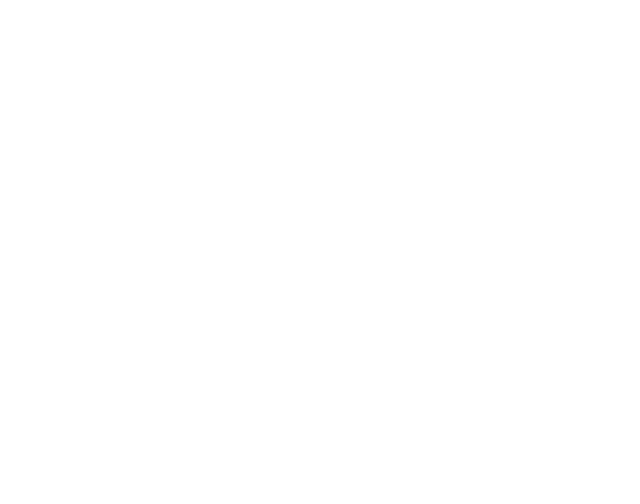

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection

# Example: fake simplified data (replace with your df)
# df must have: start_lat, start_lon, end_lat, end_lon, start_hour, end_hour
# Compute midpoints for the curve
def arc_points(x0, y0, x1, y1, n=30):
    """Generate curved line between 2 points"""
    xs = np.linspace(x0, x1, n)
    ys = np.linspace(y0, y1, n)
    curve = ys + 0.3 * np.sin(np.linspace(0, np.pi, n))  # add gentle arc
    return np.column_stack([xs, curve])

# Ensure sequential index
df = df.reset_index(drop=True)

# Precompute arcs
arcs = [arc_points(row.start_lon, row.start_lat, row.end_lon, row.end_lat)
        for _, row in df.iterrows()]

def update(frame):
    t = (frame / 240) * 24
    active = df[(df.start_hour <= t) & (df.end_hour >= t)]
    if active.empty:
        lc.set_segments([])
        return [lc]
    segs = [arcs[i] for i in active.index]
    colors = plt.cm.plasma((active.start_hour % 24) / 24)
    lc.set_segments(segs)
    lc.set_color(colors)
    lc.set_alpha(0.3 + 0.7 * np.sin((frame/10) % np.pi)**2)
    return [lc]

# Plot setup
fig, ax = plt.subplots(figsize=(8,6))
ax.set_facecolor("black")
ax.set_xlim(5.7, 10.5)
ax.set_ylim(45.8, 47.9)
ax.axis("off")
ax.set_title("Mobility Network Pulse — Switzerland", color="white")

# Line collection for arcs
lc = LineCollection([], linewidths=1.0, alpha=0.5)
ax.add_collection(lc)

ani = FuncAnimation(fig, update, frames=240, interval=1000/30, blit=True)
plt.show()

ani.save("mobility_network_pulse.mp4", fps=30, dpi=100)
